# EZIE Mag - Weekly Notebook

**Project:** EZIE Mag Summer Research Project

This notebook is **Stage 2** of the EZIE Mag pipeline: it loads
multiple days of already-cleaned data from `data/processed/` and
produces labeled time-series plots spanning a full week.

This notebook does **no** cleaning, gap-filling, or feature
engineering of its own - all of that happens once, upstream, in the
Processing Notebook. If the days you want to look at haven't been
processed yet, run them through the Processing Notebook first.

Missing days within a week (e.g. a day with no processed file)
are skipped gracefully - the resulting plots will simply show a
gap for those days.

## 1. Setup

Import required libraries and the project's helper module.

In [1]:
import sys
import os
import datetime
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

import ezie_utils

## 2. Settings

Enter a start and end date to define the week (or any multi-day
range). Every date in that range that has a processed CSV in
`data/processed/` will be loaded; missing days are skipped with a
warning.

In [2]:
PROCESSED_DIR = "../data/processed"

start_str = input("Enter start date (YYYYMMDD): ").strip()
end_str = input("Enter end date (YYYYMMDD): ").strip()

# --- Validate both dates ---
for d in [start_str, end_str]:
    if not (d.isdigit() and len(d) == 8):
        raise ValueError(
            f"Invalid date '{d}'. Please enter exactly 8 digits in YYYYMMDD format."
        )
    try:
        datetime.datetime.strptime(d, "%Y%m%d")
    except ValueError:
        raise ValueError(f"'{d}' is not a valid calendar date.")

start_date = datetime.datetime.strptime(start_str, "%Y%m%d")
end_date = datetime.datetime.strptime(end_str, "%Y%m%d")

if end_date < start_date:
    raise ValueError(f"End date {end_str} is before start date {start_str}.")

# Build the list of every date from start to end, inclusive
DATES = []
current = start_date
while current <= end_date:
    DATES.append(current.strftime("%Y%m%d"))
    current += datetime.timedelta(days=1)

print(f"Requesting {len(DATES)} day(s): {DATES}")

Enter start date (YYYYMMDD):  20260613
Enter end date (YYYYMMDD):  20260620


Requesting 8 day(s): ['20260613', '20260614', '20260615', '20260616', '20260617', '20260618', '20260619', '20260620']


## 3. Load Data

Load and concatenate all available processed CSVs for the requested
date range. Days without a processed file are skipped with a warning
rather than causing an error - the resulting DataFrame will simply
have a gap for those days.

In [3]:
df = ezie_utils.load_processed_days(DATES, PROCESSED_DIR)

if df.empty:
    raise RuntimeError("No processed files found for any of the requested dates.")

print("Combined shape:", df.shape)
print("Time range:", df.index.min(), "to", df.index.max())

# Get the device fingerprint for plot titles
fingerprint = df["fingerprint"].dropna().unique()[0]
print(f"Device: {fingerprint}")

df.head()

Combined shape: (11520, 26)
Time range: 2026-06-13 00:00:00+00:00 to 2026-06-20 23:59:00+00:00
Device: AAAAAIzs1uUA


,tval,intt,nsamp,stid,fingerprint,lat,lon,alt,tres,ctemp,...,Ax,Ay,Az,Gx,Gy,Gz,imu_ctemp,B_total,Bh,D
timeString,,,,,,,,,,,,,,,,,,,,,
2026-06-13 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-13 00:01:00+00:00,1.781309e+09,60.0,1982.0,"""eziemag""",AAAAAIzs1uUA,32.952082,-97.255782,221.1,3.0,23.8125,...,0.157926,-0.084945,9.816555,-0.003665,-0.003665,-0.005345,23.613281,39891.504140,17985.971936,3.876270
2026-06-13 00:02:00+00:00,1.781309e+09,60.0,2030.0,"""eziemag""",AAAAAIzs1uUA,32.952075,-97.255773,221.3,3.0,23.8750,...,0.156132,-0.075972,9.818349,-0.003360,-0.004734,-0.005040,23.625000,39890.426270,17988.540937,3.876677
2026-06-13 00:03:00+00:00,1.781309e+09,60.0,2029.0,"""eziemag""",AAAAAIzs1uUA,32.952075,-97.255773,221.3,3.0,23.8125,...,0.166301,-0.087936,9.820144,-0.003512,-0.003818,-0.005803,23.593750,39890.962469,17987.606540,3.875826
2026-06-13 00:04:00+00:00,1.781309e+09,60.0,2036.0,"""eziemag""",AAAAAIzs1uUA,32.952075,-97.255773,221.3,3.0,23.7500,...,0.161516,-0.085543,9.818948,-0.002902,-0.004276,-0.005345,23.617188,39890.088054,17986.871575,3.878878


## 4. Weekly Plots: Bx, By, Bz

Time-series plots of the three raw magnetic field components across
the full date range. The x-axis uses real UTC timestamps, so missing
days or hours appear naturally as gaps rather than misleading
connections.

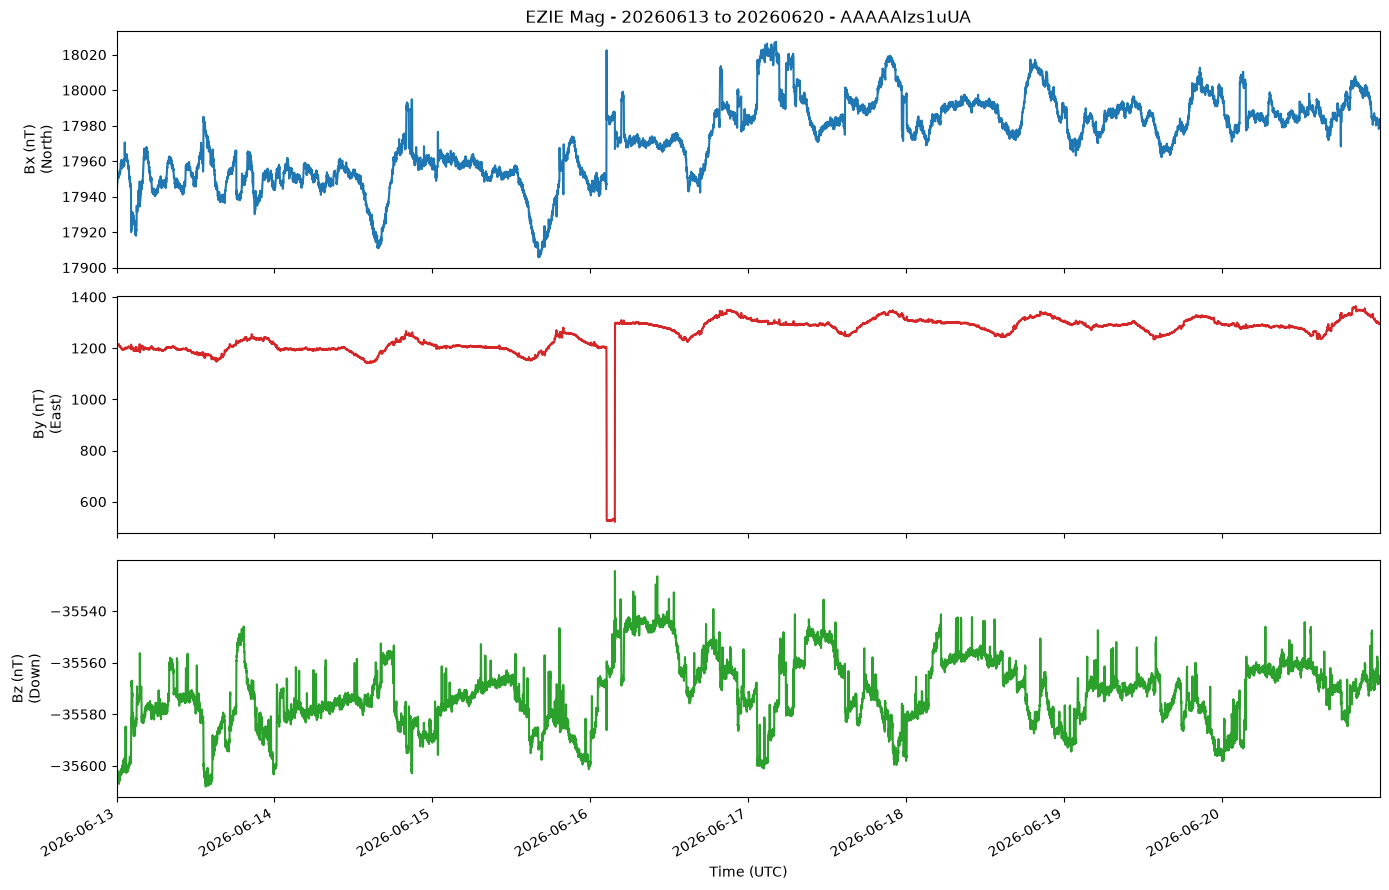

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.index, df["Bx"], color="tab:blue")
axes[0].set_ylabel("Bx (nT)\n(North)")
axes[0].set_title(f"EZIE Mag - {start_str} to {end_str} - {fingerprint}")
axes[0].set_xlim(df.index.min(), df.index.max())

axes[1].plot(df.index, df["By"], color="tab:red")
axes[1].set_ylabel("By (nT)\n(East)")
axes[1].set_xlim(df.index.min(), df.index.max())

axes[2].plot(df.index, df["Bz"], color="tab:green")
axes[2].set_ylabel("Bz (nT)\n(Down)")
axes[2].set_xlabel("Time (UTC)")
axes[2].set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Total Field Magnitude (B_total)

$$B_{total} = \sqrt{B_x^2 + B_y^2 + B_z^2}$$

Weekly view of the total field magnitude across all loaded days.

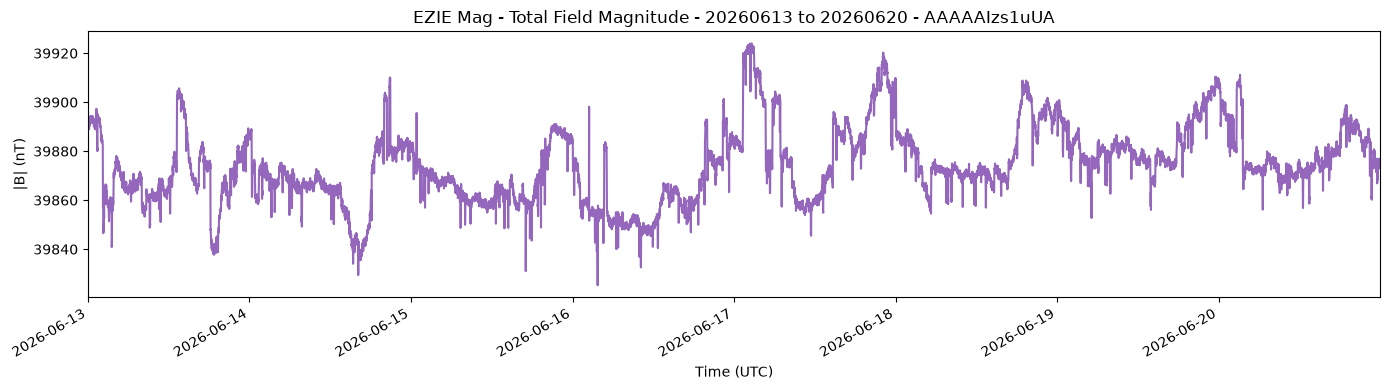

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["B_total"], color="tab:purple")
ax.set_ylabel("|B| (nT)")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE Mag - Total Field Magnitude - {start_str} to {end_str} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Horizontal Field Magnitude (Bh)

$$B_h = \sqrt{B_x^2 + B_y^2}$$

Weekly view of the horizontal field magnitude across all loaded days.

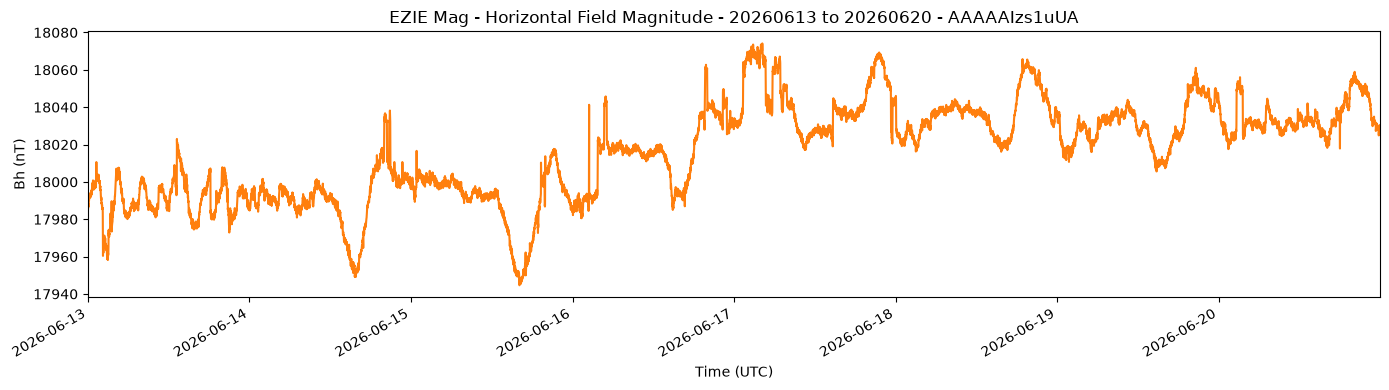

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["Bh"], color="tab:orange")
ax.set_ylabel("Bh (nT)")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE Mag - Horizontal Field Magnitude - {start_str} to {end_str} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Declination (D)

$$D = \arctan2(B_y, B_x)$$

Weekly view of the declination across all loaded days.

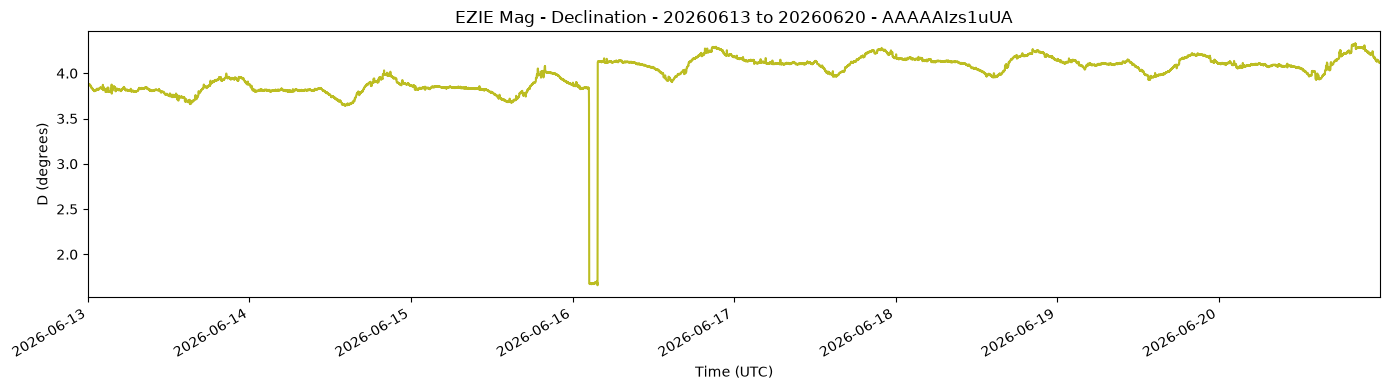

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["D"], color="tab:olive")
ax.set_ylabel("D (degrees)")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE Mag - Declination - {start_str} to {end_str} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 8. Comparison with USGS Observatories (FRD + Boulder)

Overlays EZIE data with public reference data from the USGS
Fredericksburg (FRD) and Boulder (BOU) geomagnetic observatories
across the full week.

Each dataset is **z-score normalized** before plotting:

$$z = \frac{value - \text{mean}}{\text{std}}$$

This removes both the absolute offset and the amplitude differences
between raw EZIE sensor units and calibrated observatory values,
putting everything on a common unitless scale where 0 = that
dataset's average and ±1 = one standard deviation from it. This
forces all lines onto the same visual scale regardless of their
original nT ranges, making it much easier to compare **shape** across
a full week - if a magnetic disturbance shows up in both EZIE and
the observatories at the same time, the normalized lines should move
together even if the raw amplitudes were very different.

**Known observation:** the North (Bx vs X) component tracks the
observatory data well, but the East (By vs Y) component appears
**inverted** - when observatory Y goes up, EZIE By goes down, and
vice versa. This is consistent with the sensor's physical mounting
having a flipped axis relative to true geographic East, which is
exactly what the affine calibration (rotation matrix A) is designed
to correct. This inversion is **not** corrected here - it will be
resolved when calibration is implemented.

Requires the `requests` library.

Fetching FRD...
  FRD 20260613: 1441 rows
  FRD 20260614: 1441 rows
  FRD 20260615: 1441 rows
  FRD 20260616: retrying (1/3)...
  FRD 20260616: retrying (2/3)...
  FRD 20260616: failed after 3 attempts (('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer')))
  FRD 20260617: 1441 rows
  FRD 20260618: 1441 rows
  FRD 20260619: 1441 rows
  FRD 20260620: 1441 rows
  FRD total: 10082 rows
Fetching BOU...
  BOU 20260613: 1441 rows
  BOU 20260614: 1441 rows
  BOU 20260615: 1441 rows
  BOU 20260616: 1441 rows
  BOU 20260617: 1441 rows
  BOU 20260618: 1441 rows
  BOU 20260619: 1441 rows
  BOU 20260620: 1441 rows
  BOU total: 11521 rows


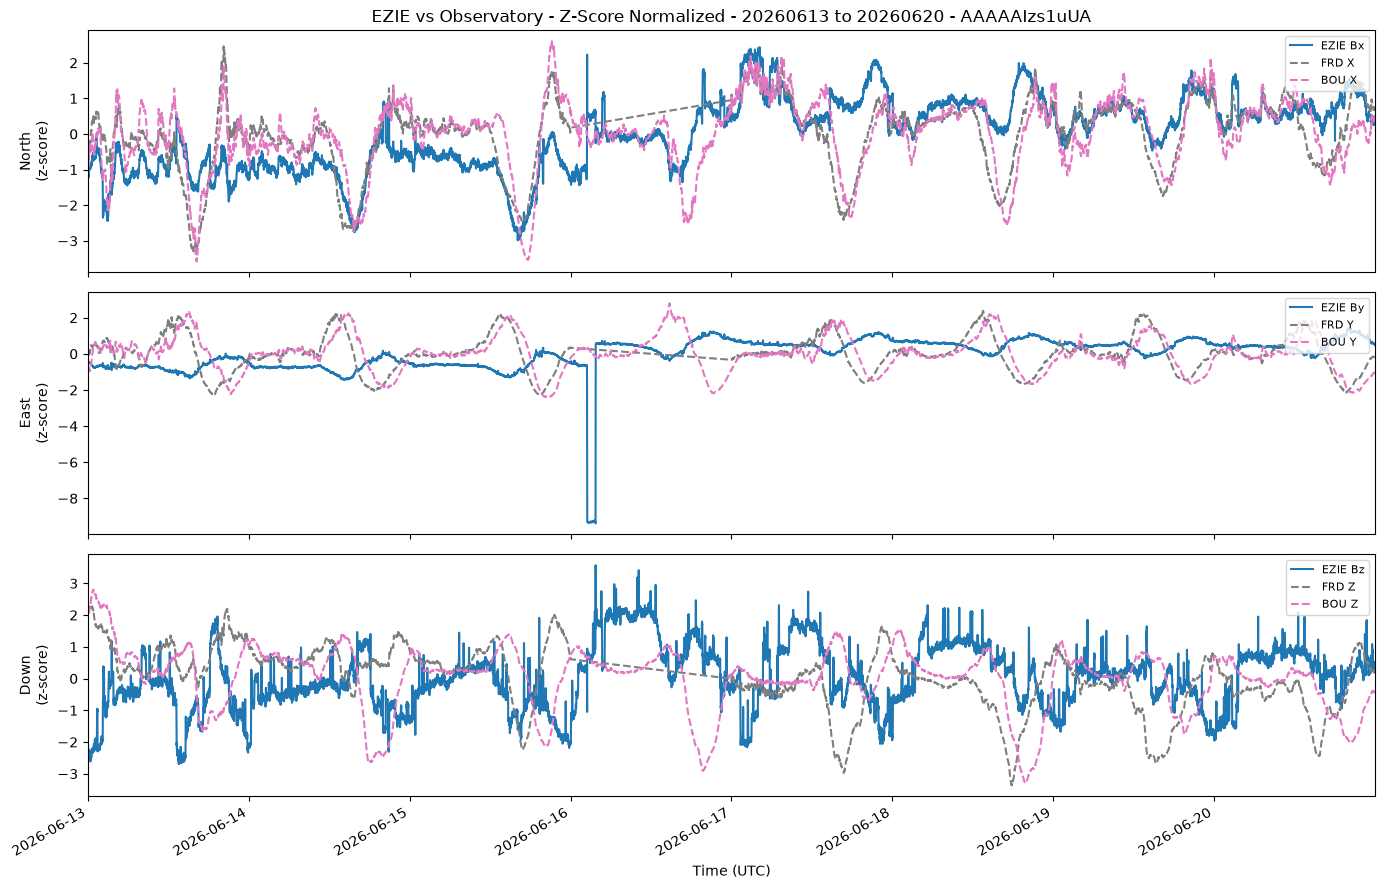

In [8]:
import requests

# --- Fetch reference data day-by-day to avoid API timeout ---
# A full week of 1-minute data in one request can exceed the USGS
# API's response time limit. Fetching one day at a time and
# concatenating avoids this.
observatories = {
    "FRD": "tab:gray",
    "BOU": "tab:pink"
}

obs_dfs = {}

for obs_id in observatories:
    print(f"Fetching {obs_id}...")
    daily_dfs = []

    for date_str in DATES:
        day_start = pd.Timestamp(date_str, tz="UTC")
        day_end = day_start + pd.Timedelta(days=1)

        url = (
            "https://geomag.usgs.gov/ws/data/"
            f"?id={obs_id}"
            f"&starttime={day_start.strftime('%Y-%m-%dT%H:%M:%SZ')}"
            f"&endtime={day_end.strftime('%Y-%m-%dT%H:%M:%SZ')}"
            f"&elements=X,Y,Z,F"
            f"&sampling_period=60"
            f"&format=json"
        )

        try:
            # Retry up to 3 times with increasing timeout, since the
            # USGS API can be slow/intermittent
            for attempt in range(3):
                try:
                    response = requests.get(url, timeout=60)
                    response.raise_for_status()
                    data = response.json()
                    break
                except Exception:
                    if attempt < 2:
                        print(f"  {obs_id} {date_str}: retrying ({attempt + 1}/3)...")
                    else:
                        raise

            times = pd.to_datetime(data["times"])
            day_df = pd.DataFrame(index=times)
            for element in data["values"]:
                name = element["metadata"]["element"]
                day_df[name] = element["values"]

            daily_dfs.append(day_df)
            print(f"  {obs_id} {date_str}: {day_df.shape[0]} rows")

        except Exception as e:
            print(f"  {obs_id} {date_str}: failed after 3 attempts ({e})")

    if daily_dfs:
        # Concatenate all days and drop any duplicate timestamps
        # (the overlapping midnight rows from consecutive days)
        combined = pd.concat(daily_dfs).sort_index()
        combined = combined[~combined.index.duplicated(keep="first")]
        obs_dfs[obs_id] = combined
        print(f"  {obs_id} total: {obs_dfs[obs_id].shape[0]} rows")
    else:
        print(f"  {obs_id}: no data loaded")

# --- Overlay plots: z-score normalized on a shared axis ---
components = [
    ("Bx", "X", "North"),
    ("By", "Y", "East"),
    ("Bz", "Z", "Down")
]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, (ezie_col, obs_col, label) in zip(axes, components):
    # EZIE z-score
    ezie_mean = df[ezie_col].mean()
    ezie_std = df[ezie_col].std()
    ezie_z = (df[ezie_col] - ezie_mean) / ezie_std
    ax.plot(df.index, ezie_z, color="tab:blue", label=f"EZIE {ezie_col}")

    # Observatory z-scores
    for obs_id, color in observatories.items():
        if obs_id in obs_dfs:
            obs_mean = obs_dfs[obs_id][obs_col].mean()
            obs_std = obs_dfs[obs_id][obs_col].std()
            obs_z = (obs_dfs[obs_id][obs_col] - obs_mean) / obs_std
            ax.plot(
                obs_dfs[obs_id].index, obs_z,
                color=color, linestyle="--", label=f"{obs_id} {obs_col}"
            )

    ax.set_ylabel(f"{label}\n(z-score)")
    ax.set_xlim(df.index.min(), df.index.max())
    ax.legend(loc="upper right", fontsize=8)

axes[0].set_title(f"EZIE vs Observatory - Z-Score Normalized - {start_str} to {end_str} - {fingerprint}")
axes[-1].set_xlabel("Time (UTC)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 9. Total Field and Horizontal Field - Observatory Comparison

Z-score normalized comparison of EZIE's derived fields against the
corresponding observatory quantities:

- **B_total** vs observatory **F** (total field magnitude)
- **Bh** vs observatory **H** (horizontal field magnitude)

Same normalization as Section 8 - each dataset is independently
z-scored so shape/trend can be compared directly regardless of
absolute scale differences.

Fetching H, F for FRD...
  FRD 20260613: 1441 rows
  FRD 20260614: 1441 rows
  FRD 20260615: 1441 rows
  FRD 20260616: 1441 rows
  FRD 20260617: 1441 rows
  FRD 20260618: 1441 rows
  FRD 20260619: 1441 rows
  FRD 20260620: 1441 rows
  FRD total: 11521 rows
Fetching H, F for BOU...
  BOU 20260613: 1441 rows
  BOU 20260614: 1441 rows
  BOU 20260615: 1441 rows
  BOU 20260616: 1441 rows
  BOU 20260617: 1441 rows
  BOU 20260618: 1441 rows
  BOU 20260619: 1441 rows
  BOU 20260620: 1441 rows
  BOU total: 11521 rows


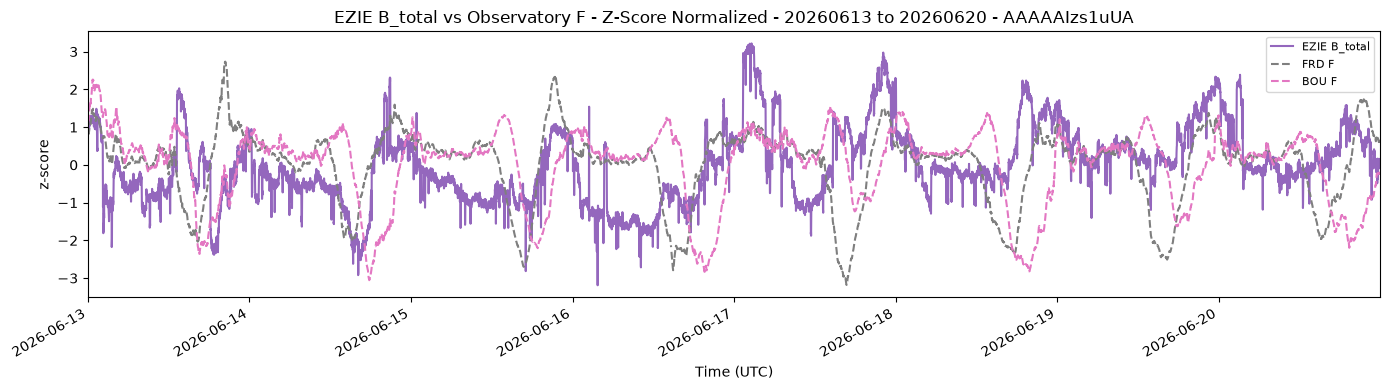

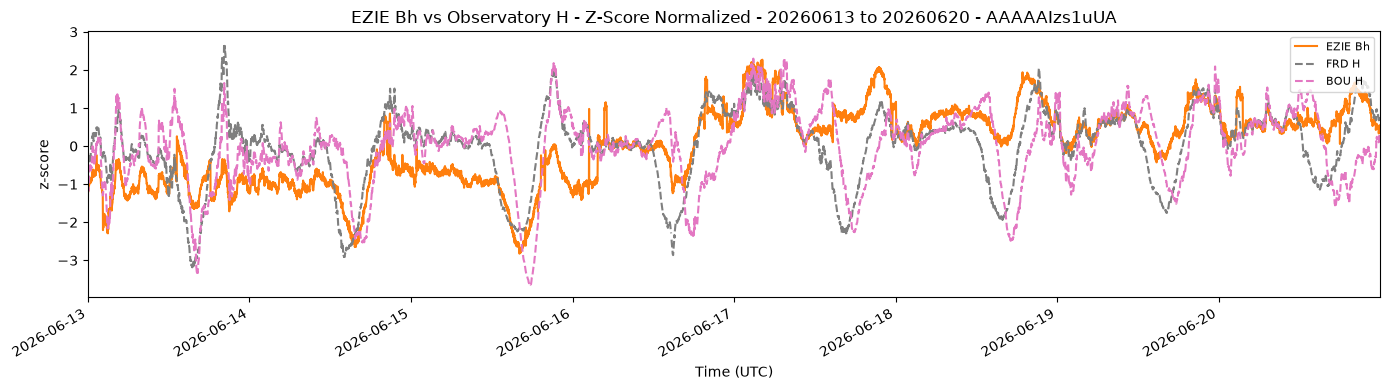

In [10]:
# --- Fetch H element from observatories (if not already fetched) ---
# Section 8 fetched X, Y, Z, F — we need H as well for the Bh
# comparison. Re-fetch with H included.
obs_dfs_hf = {}

for obs_id in observatories:
    print(f"Fetching H, F for {obs_id}...")
    daily_dfs = []

    for date_str in DATES:
        day_start = pd.Timestamp(date_str, tz="UTC")
        day_end = day_start + pd.Timedelta(days=1)

        url = (
            "https://geomag.usgs.gov/ws/data/"
            f"?id={obs_id}"
            f"&starttime={day_start.strftime('%Y-%m-%dT%H:%M:%SZ')}"
            f"&endtime={day_end.strftime('%Y-%m-%dT%H:%M:%SZ')}"
            f"&elements=H,F"
            f"&sampling_period=60"
            f"&format=json"
        )

        try:
            for attempt in range(3):
                try:
                    response = requests.get(url, timeout=60)
                    response.raise_for_status()
                    data = response.json()
                    break
                except Exception:
                    if attempt < 2:
                        print(f"  {obs_id} {date_str}: retrying ({attempt + 1}/3)...")
                    else:
                        raise

            times = pd.to_datetime(data["times"])
            day_df = pd.DataFrame(index=times)
            for element in data["values"]:
                name = element["metadata"]["element"]
                day_df[name] = element["values"]

            daily_dfs.append(day_df)
            print(f"  {obs_id} {date_str}: {day_df.shape[0]} rows")

        except Exception as e:
            print(f"  {obs_id} {date_str}: failed after 3 attempts ({e})")

    if daily_dfs:
        combined = pd.concat(daily_dfs).sort_index()
        combined = combined[~combined.index.duplicated(keep="first")]
        obs_dfs_hf[obs_id] = combined
        print(f"  {obs_id} total: {obs_dfs_hf[obs_id].shape[0]} rows")
    else:
        print(f"  {obs_id}: no data loaded")

# --- B_total vs observatory F ---
fig, ax = plt.subplots(figsize=(14, 4))

ezie_mean = df["B_total"].mean()
ezie_std = df["B_total"].std()
ezie_z = (df["B_total"] - ezie_mean) / ezie_std
ax.plot(df.index, ezie_z, color="tab:purple", label="EZIE B_total")

for obs_id, color in observatories.items():
    if obs_id in obs_dfs_hf and "F" in obs_dfs_hf[obs_id].columns:
        obs_mean = obs_dfs_hf[obs_id]["F"].mean()
        obs_std = obs_dfs_hf[obs_id]["F"].std()
        obs_z = (obs_dfs_hf[obs_id]["F"] - obs_mean) / obs_std
        ax.plot(
            obs_dfs_hf[obs_id].index, obs_z,
            color=color, linestyle="--", label=f"{obs_id} F"
        )

ax.set_ylabel("z-score")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE B_total vs Observatory F - Z-Score Normalized - {start_str} to {end_str} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# --- Bh vs observatory H ---
fig, ax = plt.subplots(figsize=(14, 4))

ezie_mean = df["Bh"].mean()
ezie_std = df["Bh"].std()
ezie_z = (df["Bh"] - ezie_mean) / ezie_std
ax.plot(df.index, ezie_z, color="tab:orange", label="EZIE Bh")

for obs_id, color in observatories.items():
    if obs_id in obs_dfs_hf and "H" in obs_dfs_hf[obs_id].columns:
        obs_mean = obs_dfs_hf[obs_id]["H"].mean()
        obs_std = obs_dfs_hf[obs_id]["H"].std()
        obs_z = (obs_dfs_hf[obs_id]["H"] - obs_mean) / obs_std
        ax.plot(
            obs_dfs_hf[obs_id].index, obs_z,
            color=color, linestyle="--", label=f"{obs_id} H"
        )

ax.set_ylabel("z-score")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"EZIE Bh vs Observatory H - Z-Score Normalized - {start_str} to {end_str} - {fingerprint}")
ax.set_xlim(df.index.min(), df.index.max())
ax.legend(loc="upper right", fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 10. Weekly Summary Statistics

Overview of the magnetic field data across the full date range -
useful for weekly reports and spotting day-to-day trends or anomalies.

In [11]:
print(f"Date range: {start_str} to {end_str}")
print(f"Total rows: {len(df)}")
print(f"Missing minutes: {df['Bx'].isna().sum()}")
print()

df[["Bx", "By", "Bz", "B_total", "Bh", "D"]].describe()

Date range: 20260613 to 20260620
Total rows: 11520
Missing minutes: 6



,Bx,By,Bz,B_total,Bh,D
count,11514.000000,11514.000000,11514.000000,11514.000000,11514.000000,11514.000000
mean,17972.632071,1253.591529,-35572.121076,39874.419547,18016.463287,3.989704
std,22.395998,78.097757,13.346847,15.406143,25.421292,0.245514
min,17905.796296,520.821676,-35608.061547,39825.280411,17944.656703,1.658550
25%,17954.848236,1205.439642,-35580.420973,39864.205228,17994.811355,3.840627
50%,17975.098474,1271.716243,-35572.454162,39872.959210,18020.459436,4.044822
75%,17989.188600,1297.831456,-35563.206022,39883.224486,18035.465273,4.127068
max,18027.248664,1363.057216,-35524.460321,39923.984950,18074.135937,4.329279
